In [ ]:
#Persiapan Visualisasi Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid", palette="Set2")
df = pd.read_csv(r'D:\Michael Road To Data Analyst\Dataset\SampleSuperstore.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


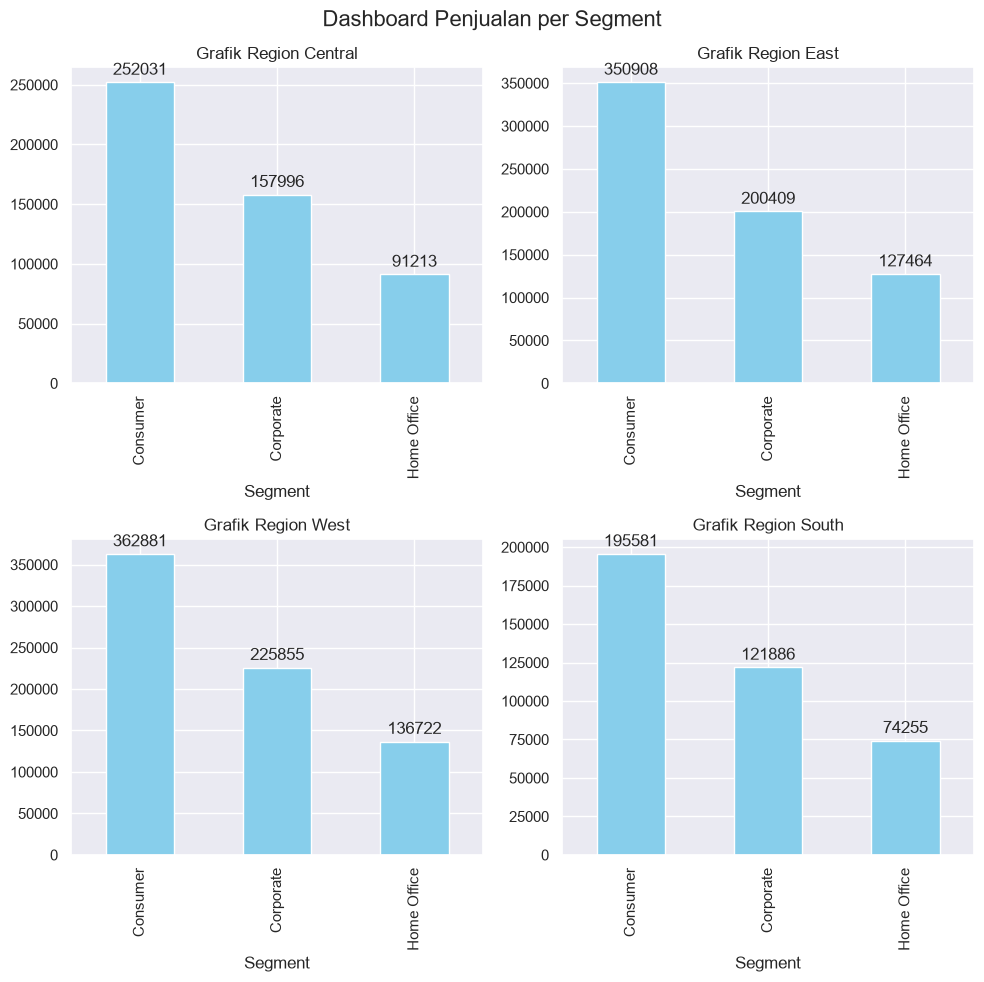

In [ ]:
#Membuat Dashboard Penjualan per Segment
fig, ax = plt.subplots(2,2, figsize=(10,10))
fig.suptitle('Dashboard Penjualan per Segment', fontsize=16)
ax[0,0].set_title('Grafik Region Central')
ax[0,1].set_title('Grafik Region East')
ax[1,0].set_title('Grafik Region West')
ax[1,1].set_title('Grafik Region South')

data = ['Central', 'East', 'West', 'South']
koordinat = [(0,0), (0,1), (1,0), (1,1)]
for wilayah, koordinat in zip(data,koordinat):
    df_region = df[df['Region'] == wilayah]
    sales_region = df_region.groupby('Segment')['Sales'].sum()
    sales_region.plot(kind='bar', ax=ax[koordinat], color='skyblue')
    ax[koordinat].bar_label(ax[koordinat].containers[0], padding = 3, fmt = '%.0f')
plt.tight_layout()
plt.show()

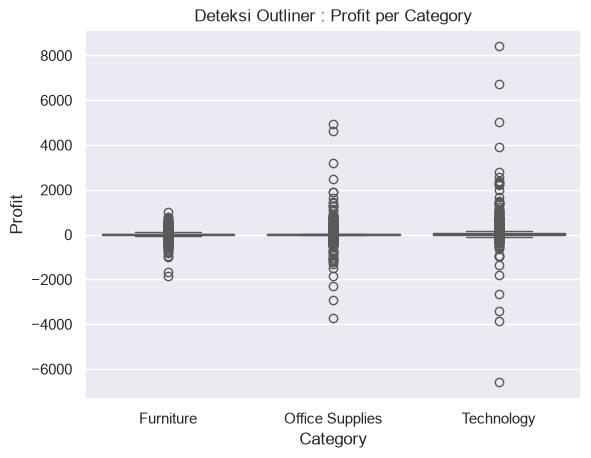

In [ ]:
#Mendeteksi Outliner : Profit per Category dengan Boxplot
sns.boxplot(data=df, x='Category', y='Profit')
plt.title('Deteksi Outliner : Profit per Category')
plt.show()

             Sales    Profit  Quantity  Discount
Sales     1.000000  0.479064  0.200795 -0.028190
Profit    0.479064  1.000000  0.066253 -0.219487
Quantity  0.200795  0.066253  1.000000  0.008623
Discount -0.028190 -0.219487  0.008623  1.000000
-0.21948745637176795


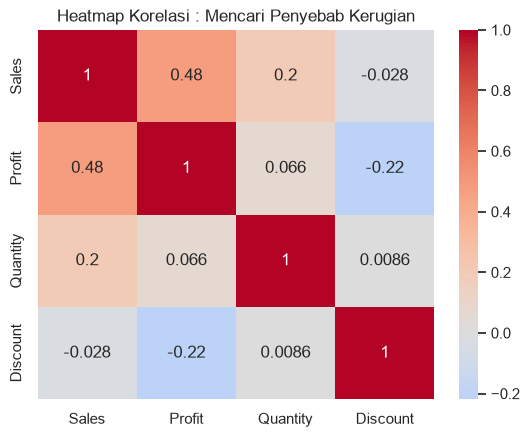

In [ ]:
#Mencari Penyebab Kerugian : Korelasi antara Sales, Profit, Quantity, dan Discount
nilai_korelasi = df[['Sales','Profit','Quantity','Discount']].corr()
print(nilai_korelasi)
print(nilai_korelasi.loc['Discount','Profit'])
sns.heatmap(nilai_korelasi,annot=True, cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi : Mencari Penyebab Kerugian')
plt.show()

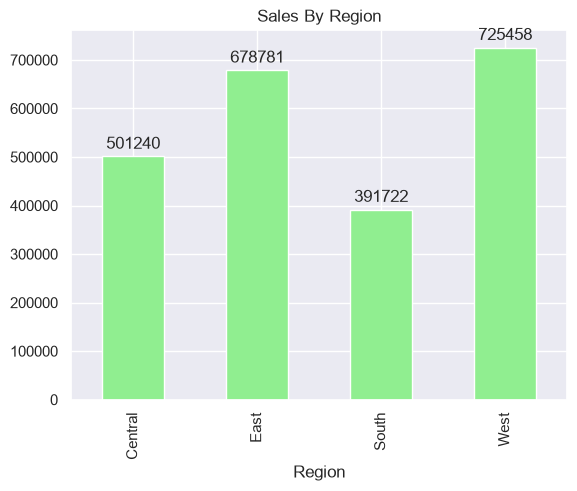

In [ ]:
#Visualisasi Data : Sales by Region
sales_region = df.groupby('Region')['Sales'].sum()
ax = sales_region.plot(kind='bar', color='lightgreen')
ax.bar_label(ax.containers[0], padding = 3, fmt = '%.0f')
plt.title('Sales By Region')
plt.show()

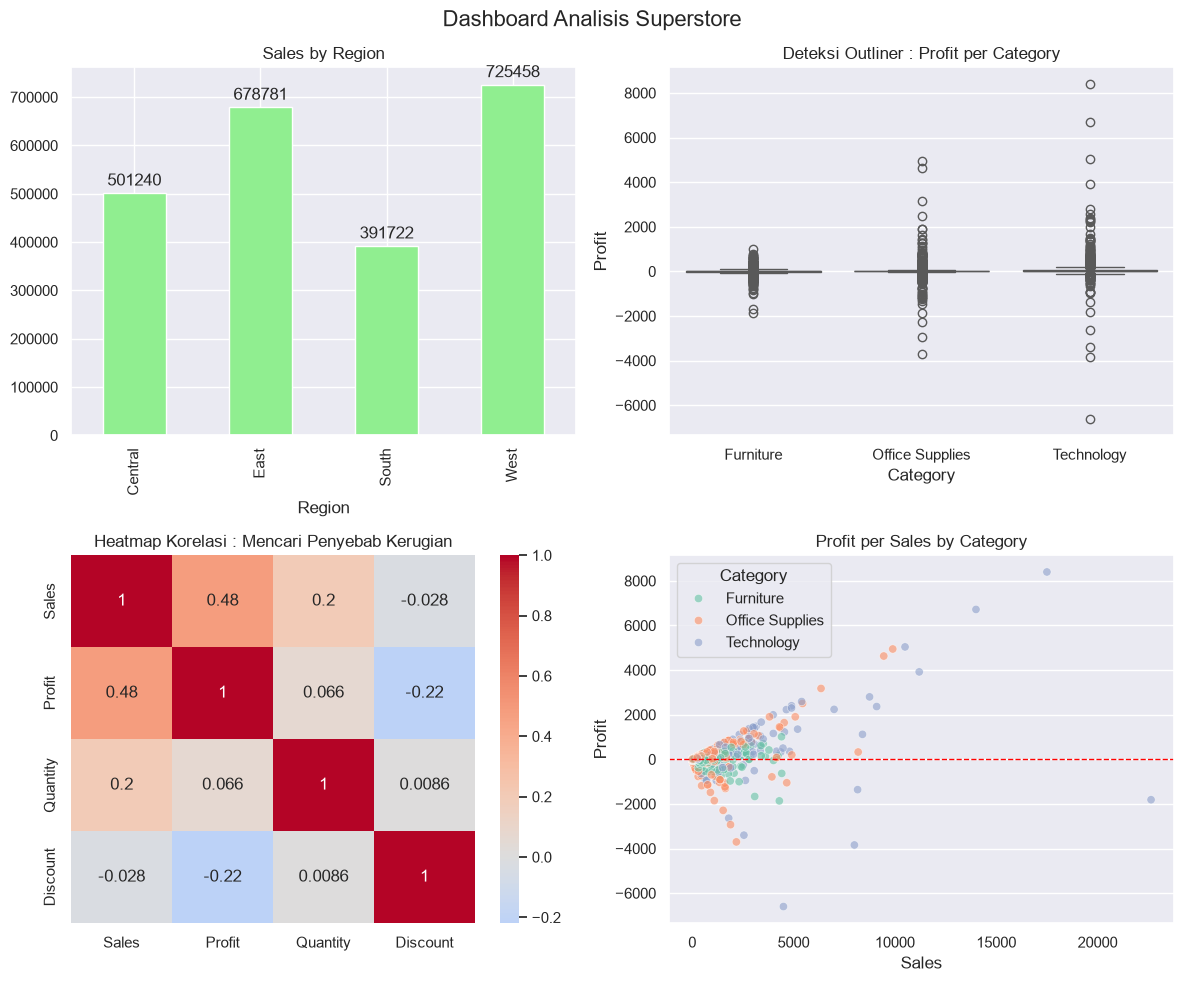

In [ ]:
#Menggabungkan semua visualisasi menjadi satu Dashboard Analisis Superstore
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Dashboard Analisis Superstore', fontsize=16)

#Sales by Region
sales_region.plot(kind='bar', color='lightgreen',ax=axes[0,0])
axes[0,0].set_title('Sales by Region')
axes[0,0].bar_label(axes[0,0].containers[0], padding = 3, fmt = '%.0f')

#Profit per Category
sns.boxplot(data=df, x='Category', y='Profit', ax=axes[0,1])
axes[0,1].set_title('Deteksi Outliner : Profit per Category')

#Korelasi Heatmap
sns.heatmap(nilai_korelasi,annot=True, cmap='coolwarm', center=0,ax=axes[1,0])
axes[1,0].set_title('Heatmap Korelasi : Mencari Penyebab Kerugian')

#Profit per Sales by Category
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category', alpha = 0.6, ax=axes[1,1])
axes[1,1].set_title('Profit per Sales by Category')
axes[1,1].axhline(0, color ='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

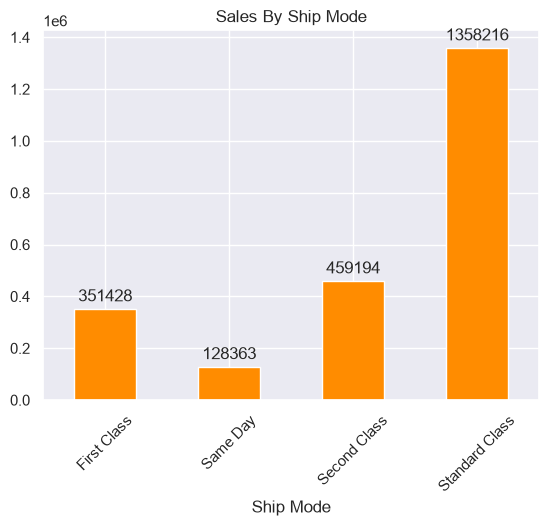

'Ship Mode Standart Class mencetak Penjualan terbesar, terlepas dari profit yang dihasilkan. Hal ini dapat menjadi pertimbangan untuk strategi pengiriman barang agar lebih menguntungkan'

In [86]:
#Visualisasi Data : Sales by Ship Mode
sales_shipmode = df.groupby('Ship Mode')['Sales'].sum()
ax = sales_shipmode.plot(kind='bar', color='darkorange')
ax.bar_label(ax.containers[0], padding = 3, fmt = '%.0f')
plt.xticks(rotation=45)
plt.title('Sales By Ship Mode')
plt.show()

'Kesimpulan:'
'Ship Mode Standart Class mencetak Penjualan terbesar, terlepas dari profit yang dihasilkan. Hal ini dapat menjadi pertimbangan untuk strategi pengiriman barang agar lebih menguntungkan'
